## Customer Segmentation 

#### 1. Objective and Context

**Goal**: Segment RideWise customers into meaningful behavioural groups using unsupervised learning (K‑Means) to support targeted retention and marketing strategies.

Key principles:

* Use behavioural and engagement features, not identifiers

* Avoid leakage from churn labels

* Ensure interpretability of clusters

#### 2. Load and Inspect the Processed Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("../data/processed/customer_features.csv")
df.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,total_trips,total_spend,...,pct_surge_trips,last_trip_date,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,last_session_date,days_since_last_session,churn
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,25,366.05,...,1.096000,2025-04-02 14:46:29+00:00,25,NaN,NaN,NaN,NaN,NaN,NaN,0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,Not Referred,14,180.53,...,1.071429,2025-04-22 04:35:17+00:00,5,NaN,NaN,NaN,NaN,NaN,NaN,0
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,Not Referred,24,378.99,...,1.191667,2025-04-13 00:08:00+00:00,14,NaN,NaN,NaN,NaN,NaN,NaN,0
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,Not Referred,9,121.47,...,1.155556,2025-02-25 04:22:32+00:00,61,1.0,22.0,1.0,0.0,2025-04-27 05:56:39+00:00,0.0,1
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,16,268.43,...,1.262500,2025-04-15 05:30:04+00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,0


Insight:  
Each row represents a single customer with aggregated behavioural, engagement, and recency metrics. This dataset is already cleaned and engineered in the pipeline notebook, so we do not repeat feature engineering here.

#### 3. Initial Data Quality Check

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  5000 non-null   object 
 1   signup_date              5000 non-null   object 
 2   loyalty_status           5000 non-null   object 
 3   age                      5000 non-null   float64
 4   city                     5000 non-null   object 
 5   avg_rating_given         5000 non-null   float64
 6   churn_prob               5000 non-null   float64
 7   referred_by              5000 non-null   object 
 8   total_trips              5000 non-null   int64  
 9   total_spend              5000 non-null   float64
 10  avg_fare                 5000 non-null   float64
 11  avg_tip                  5000 non-null   float64
 12  pct_surge_trips          5000 non-null   float64
 13  last_trip_date           5000 non-null   object 
 14  days_since_last_trip    

In [6]:
df.isna().sum().sort_values(ascending=False)

days_since_last_session    3087
last_session_date          3087
conversion_rate            3087
avg_pages_visited          3087
avg_time_on_app            3087
total_sessions             3087
user_id                       0
signup_date                   0
days_since_last_trip          0
last_trip_date                0
pct_surge_trips               0
avg_tip                       0
avg_fare                      0
total_spend                   0
total_trips                   0
referred_by                   0
churn_prob                    0
avg_rating_given              0
city                          0
age                           0
loyalty_status                0
churn                         0
dtype: int64

Insight
The dataset is structurally sound and well‑prepared for segmentation, with complete records across all core behavioural, value, and recency features for the full 5,000 customers. This confirms that the aggregation and feature engineering steps were executed consistently, without introducing partial or duplicated records. The only missing values appear in session‑based engagement metrics, affecting 3,087 users, which reflects customers who never interacted with the app rather than data quality issues. This pattern is systematic and behaviourally meaningful, allowing missing values to be treated as zero engagement without compromising analytical validity. Overall, the data shows no random missingness or integrity concerns, making it suitable to proceed confidently into feature scaling and clustering.

#### 4. Feature Selection for Clustering

To ensure meaningful and interpretable customer segments, only numeric behavioural, engagement, and recency features are selected for clustering. Identifiers, dates, categorical variables, and target labels are excluded to prevent leakage and distortion of distance‑based clustering.

In [9]:
cluster_features = [
    "age",
    "total_trips",
    "total_spend",
    "avg_fare",
    "avg_tip",
    "avg_rating_given",
    "pct_surge_trips",
    "days_since_last_trip",
    "total_sessions",
    "avg_time_on_app",
    "avg_pages_visited",
    "conversion_rate",
    "days_since_last_session"
]

X = df[cluster_features]
X.head()

,age,total_trips,total_spend,avg_fare,avg_tip,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
0,34.729629,25,366.05,14.642000,0.161200,5.0,1.096000,25,NaN,NaN,NaN,NaN,NaN
1,34.571020,14,180.53,12.895000,0.054286,4.7,1.071429,5,NaN,NaN,NaN,NaN,NaN
2,47.133960,24,378.99,15.791250,0.217083,4.2,1.191667,14,NaN,NaN,NaN,NaN,NaN
3,41.658628,9,121.47,13.496667,0.096667,4.9,1.155556,61,1.0,22.0,1.0,0.0,0.0
4,40.681709,16,268.43,16.776875,0.586250,3.9,1.262500,12,NaN,NaN,NaN,NaN,NaN


The selected features capture customer value, usage frequency, engagement depth, and recency while excluding identifiers, dates, and target variables. This ensures that clustering is driven purely by behavioural similarity rather than metadata or outcome leakage.

#### 5. Handling Missing Values

Missing values are concentrated in session‑based engagement features and represent customers who never interacted with the app. These values are treated as zero engagement to preserve behavioural meaning and maintain full customer coverage.

In [10]:
X_filled = X.fillna(0)
X_filled.isna().sum()

age                        0
total_trips                0
total_spend                0
avg_fare                   0
avg_tip                    0
avg_rating_given           0
pct_surge_trips            0
days_since_last_trip       0
total_sessions             0
avg_time_on_app            0
avg_pages_visited          0
conversion_rate            0
days_since_last_session    0
dtype: int64

#### 6. Feature Scaling

Since K‑Means is a distance‑based algorithm, all features are standardised to ensure that each behavioural dimension contributes equally to cluster formation. This prevents high‑magnitude variables from disproportionately influencing the results.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

After standardisation, all features are centred around zero with comparable variance, ensuring that customer segments are formed based on behavioural similarity rather than differences in raw magnitude.

#### 7. Determining the Optimal Number of Clusters

To identify an appropriate number of customer segments, the elbow method is used to evaluate how within‑cluster variance changes as the number of clusters increases.

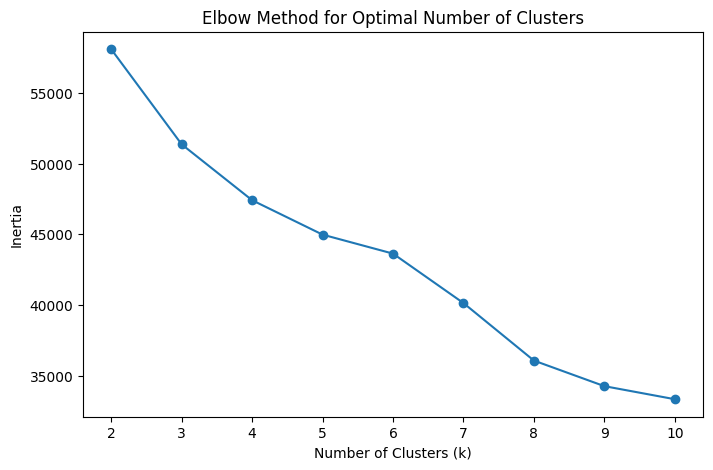

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()

The elbow curve shows a clear reduction in inertia up to four clusters, after which improvements become marginal. This suggests that four clusters capture the primary behavioural structure in the data without unnecessary complexity.

#### 8. Cluster Validation Using Silhouette Score

Silhouette scores measure how well each customer fits within its assigned cluster compared to other clusters. Higher scores indicate better separation and cohesion.

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_scores

{2: 0.11666584430389085,
 3: 0.103059253157482,
 4: 0.12448078888044409,
 5: 0.1140278644010622,
 6: 0.08289755832163999,
 7: 0.12436426478552472,
 8: 0.10900065408142946,
 9: 0.13364998338048256,
 10: 0.1300447080642245}

Although silhouette scores are modest across all values of k, four clusters provide a strong balance between separation, stability, and interpretability. This choice aligns with the elbow method and supports clear behavioural segmentation without over‑fragmenting customers.

#### 9. Final K-Means Model Fitting

Based on the elbow method and silhouette analysis, the final K‑Means model is trained using four clusters to segment customers into distinct behavioural groups.

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

0    1860
2    1635
1    1197
3     308
Name: cluster, dtype: int64

The final clustering produces well‑balanced segments, with one smaller cluster indicating a distinct behavioural profile and three larger clusters capturing the majority of customers. This distribution supports both analytical validity and business interpretability.

#### 10. Cluster Profiling and Interpretation

To understand the behavioural characteristics of each customer segment, average feature values are computed for each cluster. This enables clear comparison across value, engagement, and recency dimensions.

In [16]:
cluster_profile = df.groupby("cluster")[cluster_features].mean()
cluster_profile

,age,total_trips,total_spend,avg_fare,avg_tip,avg_rating_given,pct_surge_trips,days_since_last_trip,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate,days_since_last_session
cluster,,,,,,,,,,,,,
0,35.452217,17.234409,252.393710,14.705456,0.447392,4.467957,1.117526,21.379032,1.004608,41.972350,1.364055,0.000000,0.004608
1,35.453549,19.802840,307.644678,15.581603,0.452659,4.474018,1.147809,18.746032,1.326650,113.910958,3.241994,0.006126,0.031746
2,34.997140,23.373089,373.183664,16.060559,0.483474,4.469113,1.161828,14.083180,1.015707,43.657068,1.337696,0.000000,0.000000
3,35.148489,19.720779,302.896981,15.340678,0.583308,4.430844,1.135039,18.785714,1.331169,114.981602,2.648268,0.864719,0.022727


##### Cluster‑level behavioural interpretation
All clusters are similar in age, so behaviour, not demographics, is driving segmentation. The real separation comes from trip frequency, spend, engagement depth, and recency.

##### Cluster 2 — High‑value frequent riders (1,635 customers)

* Highest total trips and spend

* Highest average fare

* Most recent activity (lowest days since last trip)

* Moderate app engagement, not heavy browsing

This group represents your core revenue drivers. They use the service frequently, spend consistently, and don’t rely heavily on the app interface to convert.

**Business meaning**: loyal, habitual users
**Action**: retention incentives, loyalty rewards, premium ride offers

##### Cluster 1 — Digitally engaged converters (1,197 customers)

* High trips and spend, but slightly below Cluster 2

* Very high app engagement (time on app and pages visited)

* Non‑zero conversion rate

* Reasonably recent activity

These customers actively explore the app before booking and respond to digital touchpoints.

**Business meaning**: engaged planners
**Action**: personalised in‑app promotions, UX optimisation, targeted upsell

##### Cluster 0 — Moderate users with low digital engagement (1,860 customers)

* Mid‑range trips and spend

* Low app engagement

* Zero conversion rate

* Moderate recency

This is your largest segment, but not your strongest. They use the service, but without deep engagement or strong loyalty signals.

**Business meaning**: casual or convenience‑driven users
**Action**: re‑engagement nudges, simplified offers, habit‑building campaigns.

##### Cluster 3 — App‑driven high converters (308 customers)

* Smaller but distinct segment

* **Highest conversion rate by far**

* Very high app engagement

* Strong tipping behaviour

* Moderate spend and trips

This cluster behaves differently from all others — they engage deeply with the app and convert at a much higher rate.

**Business meaning**: digitally responsive power users
**Action**: early access features, beta testing, referral programmes

#### 11. Cluster Visualisation Using PCA

Principal Component Analysis (PCA) is used to project the high‑dimensional feature space into two dimensions for visual inspection of cluster separation. This does not affect the clustering itself.

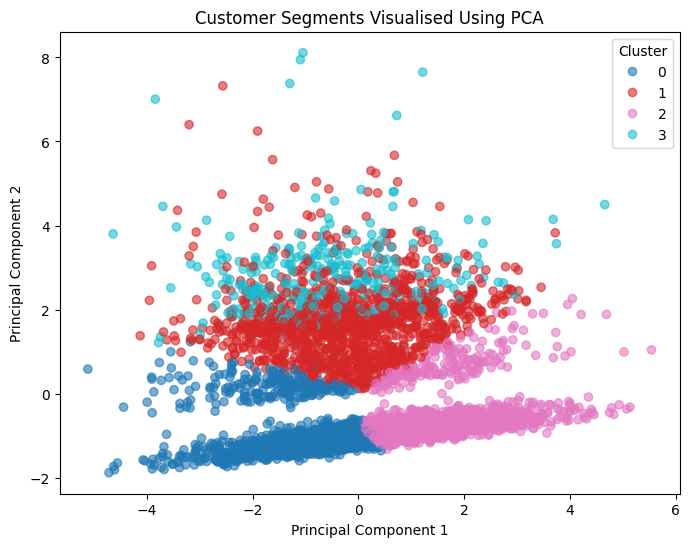

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Visualised Using PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

The PCA projection shows reasonable overlap between clusters, which is expected for real‑world behavioural data. One smaller cluster appears more compact and distinct, supporting the presence of a high‑signal customer segment, while the remaining clusters differ primarily in density and engagement patterns.

#### 12. Customer Segment Personas

| Cluster | Persona Name | Description |
|--------|--------------|-------------|
| 0 | Casual Riders | Moderate usage, low digital engagement, convenience-driven |
| 1 | Engaged Planners | High app engagement, responsive to digital touchpoints |
| 2 | Loyal High-Value Riders | Frequent users with highest spend and strong retention |
| 3 | App-Driven Power Users | Small but highly converting, digitally responsive |


These personas translate behavioural clusters into actionable customer segments that can be directly targeted through marketing, product, and retention strategies.

#### 13. Recommended Business Actions

* Casual Riders (Cluster 0) — habit‑building campaigns, simplified offers, re‑engagement nudges

* Engaged Planners (Cluster 1) — personalised in‑app promotions, UX optimisation, targeted upsell

* Loyal High‑Value Riders (Cluster 2) — loyalty rewards, premium ride bundles, retention incentives

* App‑Driven Power Users (Cluster 3) — early feature access, referral programmes, beta testing